Imports and configuration

In [2]:
# --- Imports and configuration ---
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from census import Census
from us import states
import mapclassify as mc

# --- Replace with your own Census API key ---
API_KEY = "c9cf843d2c297d7ad549b1be51dbcf62facce09c" 
YEAR = 2023  # ACS 5-year data (use 2023 for latest)
VOT_REF = 27.7  # $/hour – NYSDOT Downstate Local (2023)
ELASTICITY = 0.5  # income elasticity of value of time
NYC_COUNTIES = ["005", "047", "061", "081", "085"]  # Bronx, Kings, Manhattan, Queens, Richmond
JFK_LON, JFK_LAT = -73.7781, 40.6413  # JFK coordinates

Download ACS data for NYC census tracts

In [3]:
# --- Download ACS data for NYC census tracts (Income + Population only) ---
try:
    c = Census(API_KEY)

    vars_dict = {
        "B19013_001E": "median_household_income",  # Income
        "B01003_001E": "population_total",         # Population
    }

    frames = []
    for cnty in NYC_COUNTIES:
        data = c.acs5.state_county_tract(
            list(vars_dict.keys()),
            states.NY.fips,
            cnty,
            Census.ALL,
            year=YEAR
        )
        frames.append(pd.DataFrame(data))

    df = pd.concat(frames, ignore_index=True)
    df.rename(columns=vars_dict, inplace=True)
    df["GEOID"] = df["state"] + df["county"] + df["tract"]

    nyc_summary = c.acs5.state_place("B19013_001E", states.NY.fips, "51000", year=YEAR)

    # Extract the value and ensure it's a float
    INCOME_REF = float(nyc_summary[0]["B19013_001E"])
    print(f"Official NYC reference median household income: ${INCOME_REF:,.2f}")

    print(f"Downloaded {len(df)} census tracts for NYC.")
    print(df.head())

except Exception as e:
    print(f"Error downloading ACS data: {e}")
    print("Please verify your Census API key or network connection.")

Official NYC reference median household income: $79,713.00
Downloaded 2327 census tracts for NYC.
   median_household_income  population_total state county   tract        GEOID
0             -666666666.0            3538.0    36    005  000100  36005000100
1                 121171.0            5177.0    36    005  000200  36005000200
2                  98242.0            6481.0    36    005  000400  36005000400
3                  42957.0            6011.0    36    005  001600  36005001600
4                  67361.0            2401.0    36    005  001901  36005001901


Clean and compute socioeconomic shares

In [4]:
# --- Clean key variables ---
df["median_household_income"] = pd.to_numeric(df["median_household_income"], errors="coerce")
df = df[df["median_household_income"] > 0].copy()

df["pop"] = pd.to_numeric(df["population_total"], errors="coerce").fillna(0)

print("Cleaned data for", len(df), "tracts.")

Cleaned data for 2192 tracts.


Compute Value of Time per tract

In [5]:
# --- Compute Value of Time per tract ---
print(f"NYC reference median household income (Income_ref): ${INCOME_REF:,.2f}")

VOT_REF = 27.7      # $/hour, NYSDOT Downstate Local (2023)
ELASTICITY = 0.5      # income elasticity (Small, 2012)

# Personal VoT (income-based)
df["vot_personal"] = VOT_REF * (df["median_household_income"] / INCOME_REF) ** ELASTICITY

cols_out = ["GEOID", "median_household_income", "vot_personal"]
df[cols_out].to_csv("nyc_value_of_time_by_tract.csv", index=False)
print(f"Saved nyc_value_of_time_by_tract.csv with {len(df)} tracts")

NYC reference median household income (Income_ref): $79,713.00
Saved nyc_value_of_time_by_tract.csv with 2192 tracts


Load tract geometries

In [6]:
# --- Load tract geometries and merge with VoT data ---
tracts = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_36_tract_500k.zip")
tracts = tracts[tracts["COUNTYFP"].isin(NYC_COUNTIES)].copy()
tracts["GEOID"] = tracts["GEOID"].astype(str)

# Merge geometry with VoT data
gdf = tracts.merge(df[cols_out], on="GEOID", how="left")
gdf = gdf.to_crs(epsg=3857)  # Web Mercator for plotting

# Drop tracts with missing VoT or invalid geometries
gdf = gdf[gdf["vot_personal"].notna() & gdf.is_valid]
print(f"Final merged geometry count: {len(gdf)} tracts.")

Final merged geometry count: 2192 tracts.


Prepare classification and color bins

In [7]:
# --- Prepare classification and color bins ---
series = gdf["vot_personal"].dropna()  # drop NaNs for classification
classifier = mc.Quantiles(series, k=5)
gdf.loc[gdf["vot_personal"].notna(), "vot_class"] = classifier.yb

# Create readable labels (fixed formatting issue)
labels = [
    f"{classifier.bins[i-1]:.1f}–{classifier.bins[i]:.1f}"
    for i in range(1, len(classifier.bins))
]
print("VoT quantile bins:", labels)


VoT quantile bins: ['23.1–26.7', '26.7–29.6', '29.6–33.3', '33.3–49.1']


Plot NYC map with JFK marker

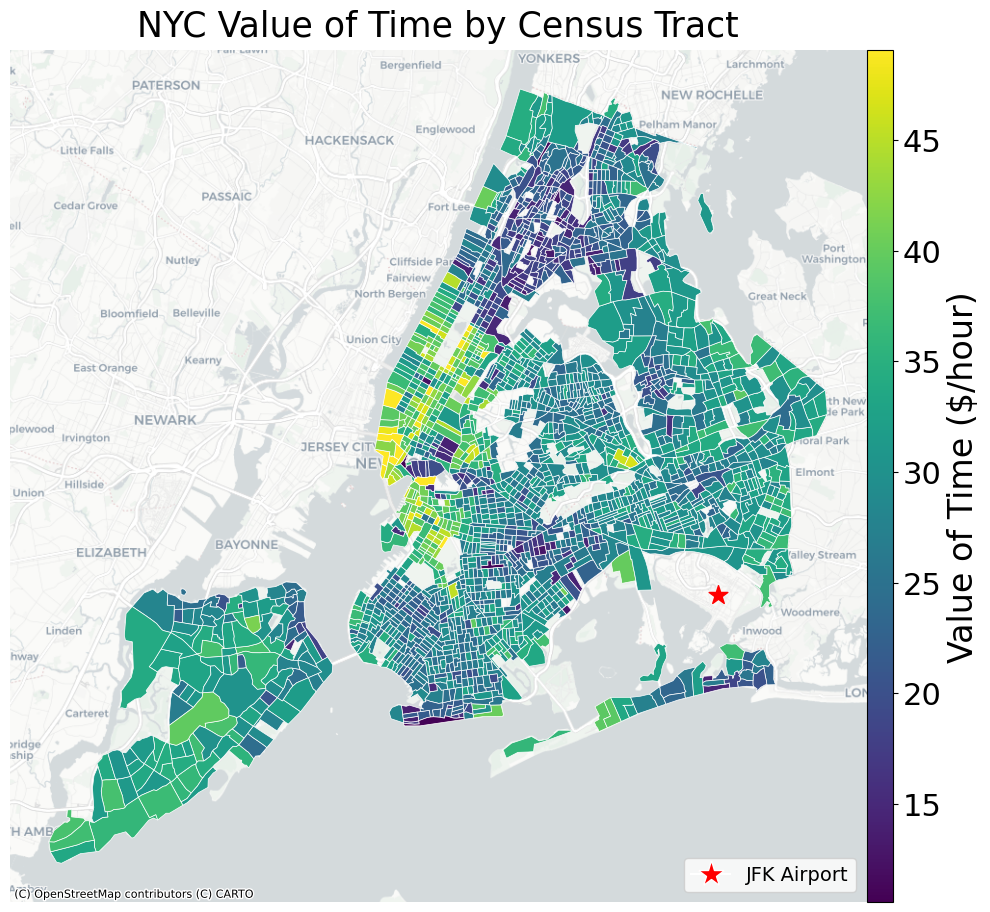

In [ ]:
import contextily as ctx
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(10, 10))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.01)  #  small pad removes gap

plot = gdf.plot(
    column="vot_personal",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    cax=cax,   # 👈 force colorbar into your axis
    legend_kwds={
        "label": "Value of Time ($/hour)",
    },
    ax=ax
)

# Modify colorbar
cax.tick_params(labelsize=22)

cax.set_ylabel("Value of Time ($/hour)", fontsize=24)

cbar_ax.set_ylabel("Value of Time ($/hour)", fontsize=16, fontweight="bold")

# Add basemap
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.CartoDB.Positron, zoom=11)

# Plot JFK marker
jfk = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([JFK_LON], [JFK_LAT]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

jfk.plot(ax=ax, markersize=200, color="red", marker="*", zorder=5)

# Create custom legend handle
jfk_legend = Line2D(
    [0], [0],
    marker='*',
    color='w',
    label='JFK Airport',
    markerfacecolor='red',
    markersize=20
)

# Add legend manually
ax.legend(handles=[jfk_legend], loc="lower right", fontsize=14)

# Aesthetics
ax.set_axis_off()
ax.set_title("NYC Value of Time by Census Tract", fontsize=25, pad=10)
plt.tight_layout()
plt.savefig("nyc_vot_map.png", dpi=300, bbox_inches="tight")
plt.show()

Taxi zones VOT

In [9]:
import os
import geopandas as gpd

# Load TLC Taxi Zones shapefile

base_dir = os.getcwd()                       
taxi_fp = os.path.join(base_dir, "taxi_zones", "taxi_zones.shp")

# Load and reproject
taxi = gpd.read_file(taxi_fp)
taxi = taxi.to_crs(gdf.crs)

print("Loaded TLC Taxi Zones shapefile")
print(f"Path used: {taxi_fp}")
print(f"Taxi zones loaded: {len(taxi)}")
print(taxi.head())


Loaded TLC Taxi Zones shapefile
Path used: c:\Users\jorge\UAM\uam_system_model\taxi_zones\taxi_zones.shp
Taxi zones loaded: 263
   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((-8258175.511 4967457.2, -8258179.518...  
1         Queens  MULTIPOLYGON (((-8217980.649 4959237.189, -821...  
2          Bronx  POLYGON ((-8220713.532 4993383.076, -8220638.4...  
3      Manhattan  POLYGON ((-8234500.207 4971984.011, -8234502.1...  
4  Staten Island  POLYGON ((-8257036.155 4948033.073, -8256954.6.

In [10]:
# Spatial intersection (tracts within taxi zones)
intersect = gpd.overlay(gdf, taxi, how="intersection")

# Compute area of intersected polygons
intersect["area"] = intersect.geometry.area

# Weight VoT by area
intersect["weighted_vot"] = intersect["vot_personal"] * intersect["area"]


In [11]:
# Compute area-weighted VoT for each taxi zone
taxi_vot = (
    intersect.groupby("LocationID")
    .apply(lambda x: x["weighted_vot"].sum() / x["area"].sum())
    .reset_index(name="vot_weighted")
)

# Merge results with taxi zone polygons
taxi = taxi.merge(taxi_vot, on="LocationID", how="left")

print("Taxi zones with VoT:", taxi["vot_weighted"].notna().sum(), "out of", len(taxi))


Taxi zones with VoT: 259 out of 263


C:\Users\jorge\AppData\Local\Temp\ipykernel_50500\128214604.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["weighted_vot"].sum() / x["area"].sum())


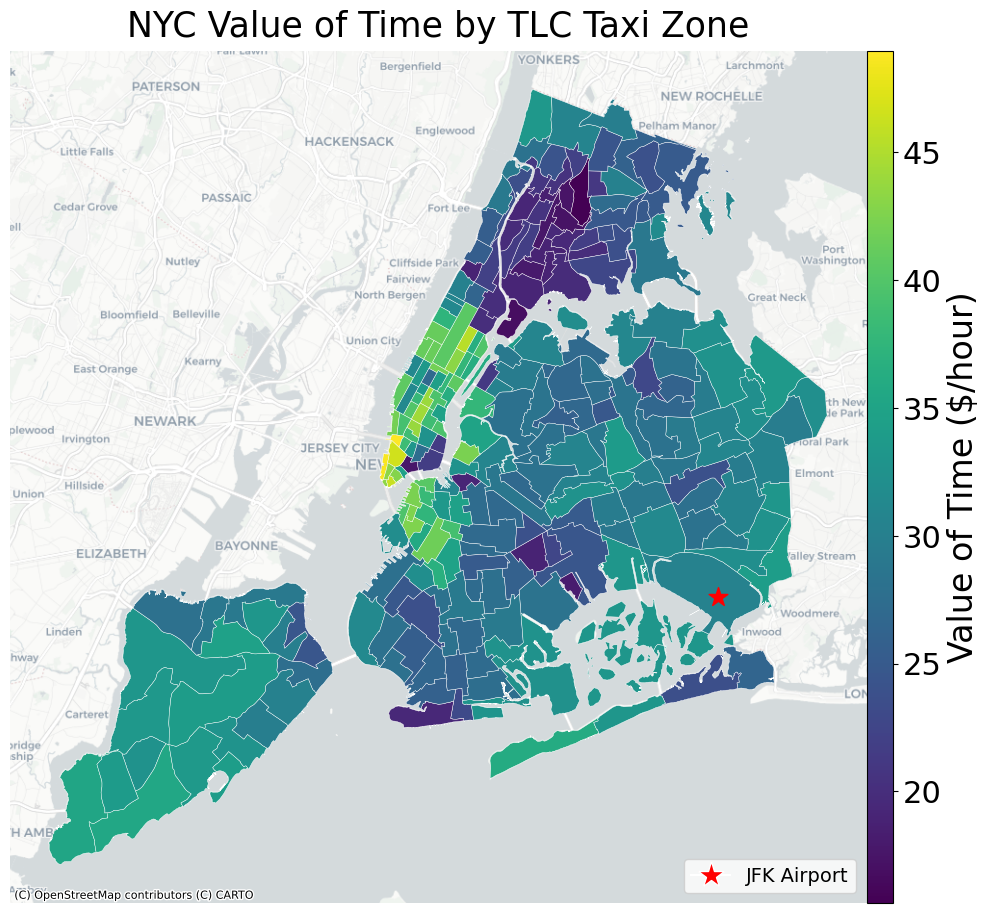

In [62]:
import contextily as ctx
import geopandas as gpd
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt

# Plot NYC map with OSM background
fig, ax = plt.subplots(figsize=(10, 10))

# Create tightly attached colorbar axis
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.01)

# Plot taxi zones
plot = taxi.plot(
    column="vot_weighted",
    cmap="viridis",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Value of Time ($/hour)",
    },
    ax=ax
)

# Match colorbar styling to first figure
cax.tick_params(labelsize=22)
cax.set_ylabel("Value of Time ($/hour)", fontsize=24)

# Add basemap
ctx.add_basemap(
    ax,
    crs=taxi.crs.to_string(),
    source=ctx.providers.CartoDB.Positron,
    zoom=11
)

# Plot JFK marker
jfk = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([JFK_LON], [JFK_LAT]),
    crs="EPSG:4326"
).to_crs(taxi.crs)

jfk.plot(
    ax=ax,
    markersize=200,
    color="red",
    marker="*",
    zorder=5
)

# Custom legend handle for JFK
jfk_legend = Line2D(
    [0], [0],
    marker="*",
    color="w",
    label="JFK Airport",
    markerfacecolor="red",
    markersize=20
)

# Add legend for JFK marker
ax.legend(handles=[jfk_legend], loc="lower right", fontsize=14)

# Aesthetics
ax.set_axis_off()
ax.set_title("NYC Value of Time by TLC Taxi Zone", fontsize=25, pad=10)

plt.tight_layout()
plt.savefig("nyc_vot_taxi_zone.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
import os

# --- Save VoT per Taxi Zone to CSV in the current working directory ---
output_path = os.path.join(os.getcwd(), "nyc_taxi_vot_zones.csv")

# Select relevant columns and drop geometry
cols_to_export = ["LocationID", "borough", "zone", "vot_weighted"]
taxi_csv = taxi[cols_to_export].copy()

# Save to CSV
taxi_csv.to_csv(output_path, index=False)

print(f"Saved Value of Time by taxi zone locally at:\n{output_path}")



Saved Value of Time by taxi zone locally at:
c:\Users\jorge\UAM\uam_system_model\nyc_taxi_vot_zones.csv
